In [456]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np 
from sympy import *

In [457]:
T= sp.symbols('T')

pi = sp.pi
n = sp.symbols('n' , positive = True , integer = True)
u = sp.symbols('u')


sp.integrate(sp.sin(n*T), (T, 0,pi))


-(-1)**n/n + 1/n

## Analytical solution 

In [458]:

radius = 2 
D = 100

a = radius
# I need to find out how polar plots in matplotlib takes information and 
u = 1   # temprature differential

# I want a value for u(r,theta) for each of these points (with accuracy n) from my analytical solution 
def simulation(N):  # pick an n value for the Fourier series
    
    r = np.linspace(0, radius , D) # this gives me each 50 possible values r can take        -np.pi , np.pi
    theta = np.linspace(-np.pi, np.pi , D) # this sets my discretisation for theta  from - pi to pi # BUG changing from linspace (-np.pi,np.pi, D) to the other way round
                                                                                                    # this has been done because of the way polar functions are wrapped counterclockwise
                                                                                                    # i need my + values to be evaluated first 
                                                                                                    # all that really does is flip it though 
                                                                                                    # python can only plot from 0 onwards tho so the graph must look like 
                                                                                                    # 0 to 2pi even though I havent done it like that 
    U = np.zeros((len(theta), len(r))) # empty array for storage of values 
    n = np.arange(1,N+1)  # an array for n going between 1 and the desired n value 
    
    

    for i in range (len(n)):
        for j in range(len(theta)):
            U[:, j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )  
    return U
    # += needed to sum the fourier terms 
#drops all values of r for a particular theta into the x column as u[:,j] selects the whole column puts all the r values in, then moves on to the next value of theta
# the colums contain all values of r for a particular value of theta 

#simulation(10)

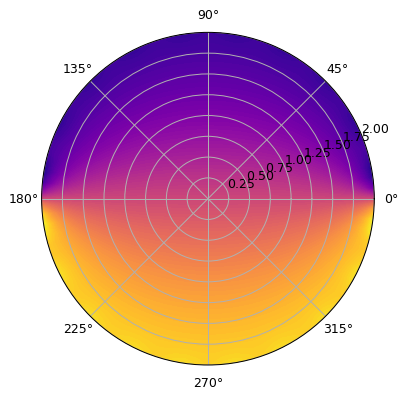

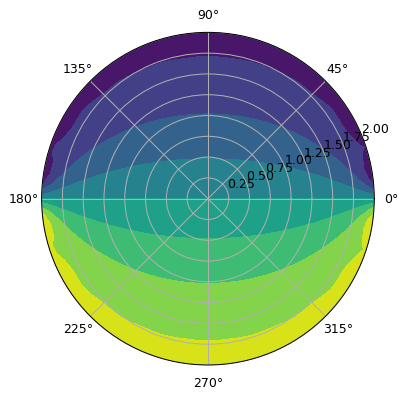

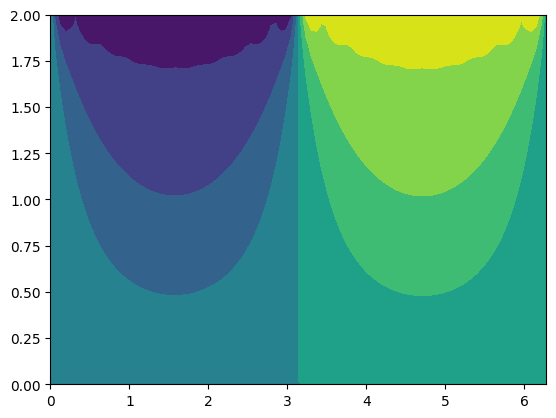

array([-1.02365228e-16, -5.28158787e-02, -1.04707169e-01, -1.54833579e-01,
       -2.02504923e-01, -2.47216943e-01, -2.88655865e-01, -3.26678719e-01,
       -3.61280052e-01, -3.92554759e-01, -4.20663559e-01, -4.45804459e-01,
       -4.68191179e-01, -4.88038084e-01, -5.05550411e-01, -5.20918379e-01,
       -5.34314001e-01, -5.45889751e-01, -5.55778457e-01, -5.64093883e-01,
       -5.70931604e-01, -5.76369928e-01, -5.80470831e-01, -5.83280832e-01,
       -5.84831718e-01, -5.85141021e-01, -5.84212238e-01, -5.82034869e-01,
       -5.78584297e-01, -5.73821445e-01, -5.67692169e-01, -5.60126441e-01,
       -5.51037437e-01, -5.40320603e-01, -5.27852740e-01, -5.13491239e-01,
       -4.97073781e-01, -4.78418983e-01, -4.57328572e-01, -4.33591801e-01,
       -4.06993109e-01, -3.77324364e-01, -3.44403068e-01, -3.08097428e-01,
       -2.68358130e-01, -2.25254786e-01, -1.79012204e-01, -1.30038219e-01,
       -7.89324911e-02, -2.64667635e-02,  2.64667635e-02,  7.89324911e-02,
        1.30038219e-01,  

In [459]:
#xs, ys = np.meshgrid(r, theta, sparse = True) # it all depends on how np is constructing this meshgrid 

zs = simulation(10)


# redefining axes not using np.meshgrid as it doesnt seem to matter
r = np.linspace(0, radius , D) 
theta = np.linspace(0, 2*np.pi , D)  #-np.pi, np.pi
#h = plt.contourf(theta, r, zs)
#plt.colorbar()
#plt.show()
plt.subplots( dpi = 90, subplot_kw=dict(projection = 'polar') )  # matplotlib constructing a plot where it takes polar arguments, converts them to cartesian and plots them 
#nicely on the interface, it takes the first value of r and the first theta for all values for theta then does the second r, which is why this works for my r by theta array U.
plt.contourf(theta , r, zs, 100, cmap = 'plasma') #100, before cmap
plt.show()

plt.subplots( dpi = 90, subplot_kw=dict(projection = 'polar') )   
plt.contourf(theta , r, zs)
plt.show()

plt.contourf(theta,r ,zs)
plt.show()

zs[49, :]

## Euclidean norm & fourier visualisation

In [460]:

#[49,:] is the last circle of theta at max r 
zs[49,:].round(2) # and zs[49,]

array([-0.  , -0.05, -0.1 , -0.15, -0.2 , -0.25, -0.29, -0.33, -0.36,
       -0.39, -0.42, -0.45, -0.47, -0.49, -0.51, -0.52, -0.53, -0.55,
       -0.56, -0.56, -0.57, -0.58, -0.58, -0.58, -0.58, -0.59, -0.58,
       -0.58, -0.58, -0.57, -0.57, -0.56, -0.55, -0.54, -0.53, -0.51,
       -0.5 , -0.48, -0.46, -0.43, -0.41, -0.38, -0.34, -0.31, -0.27,
       -0.23, -0.18, -0.13, -0.08, -0.03,  0.03,  0.08,  0.13,  0.18,
        0.23,  0.27,  0.31,  0.34,  0.38,  0.41,  0.43,  0.46,  0.48,
        0.5 ,  0.51,  0.53,  0.54,  0.55,  0.56,  0.57,  0.57,  0.58,
        0.58,  0.58,  0.59,  0.58,  0.58,  0.58,  0.58,  0.57,  0.56,
        0.56,  0.55,  0.53,  0.52,  0.51,  0.49,  0.47,  0.45,  0.42,
        0.39,  0.36,  0.33,  0.29,  0.25,  0.2 ,  0.15,  0.1 ,  0.05,
        0.  ])

In [461]:
# therefore were looking at boundary conditions of 

#zs[0,0:24] = -100 # for the 
#zs[0,24:49] = 100
periscope = zs.round(2)


np.set_printoptions(threshold=np.inf)
#periscope

In [462]:
periscope[49,:] # it looks like the top side is actually the cold side (if python truly is going anticlockwise)
# this is the rim of the cicle NOTICE!!! that the value of U jumps up and then down and then up and then down. This is because of the fourier approximation not being perfect.
# with a hight value of n this would likely be much less obvious very cool!!!!
#before saying that in the final thing make sure thats right

array([-0.  , -0.05, -0.1 , -0.15, -0.2 , -0.25, -0.29, -0.33, -0.36,
       -0.39, -0.42, -0.45, -0.47, -0.49, -0.51, -0.52, -0.53, -0.55,
       -0.56, -0.56, -0.57, -0.58, -0.58, -0.58, -0.58, -0.59, -0.58,
       -0.58, -0.58, -0.57, -0.57, -0.56, -0.55, -0.54, -0.53, -0.51,
       -0.5 , -0.48, -0.46, -0.43, -0.41, -0.38, -0.34, -0.31, -0.27,
       -0.23, -0.18, -0.13, -0.08, -0.03,  0.03,  0.08,  0.13,  0.18,
        0.23,  0.27,  0.31,  0.34,  0.38,  0.41,  0.43,  0.46,  0.48,
        0.5 ,  0.51,  0.53,  0.54,  0.55,  0.56,  0.57,  0.57,  0.58,
        0.58,  0.58,  0.59,  0.58,  0.58,  0.58,  0.58,  0.57,  0.56,
        0.56,  0.55,  0.53,  0.52,  0.51,  0.49,  0.47,  0.45,  0.42,
        0.39,  0.36,  0.33,  0.29,  0.25,  0.2 ,  0.15,  0.1 ,  0.05,
        0.  ])

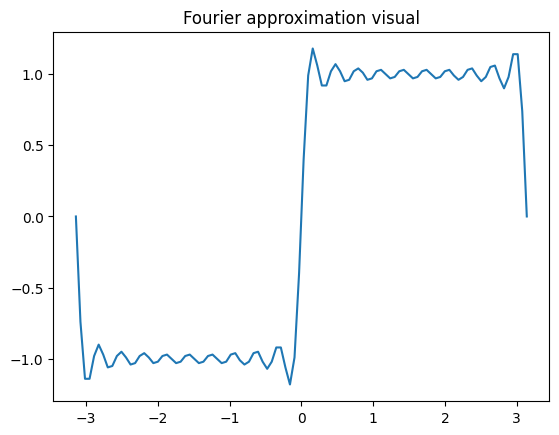

[-0.   -0.74 -1.14 -1.14 -0.98 -0.9  -0.97 -1.06 -1.05 -0.98 -0.95 -0.99
 -1.04 -1.03 -0.98 -0.96 -0.99 -1.03 -1.02 -0.98 -0.97 -1.   -1.03 -1.02
 -0.98 -0.97 -1.   -1.03 -1.02 -0.98 -0.97 -1.   -1.03 -1.02 -0.97 -0.96
 -1.01 -1.04 -1.02 -0.96 -0.95 -1.02 -1.07 -1.02 -0.92 -0.92 -1.06 -1.18
 -0.99 -0.4   0.4   0.99  1.18  1.06  0.92  0.92  1.02  1.07  1.02  0.95
  0.96  1.02  1.04  1.01  0.96  0.97  1.02  1.03  1.    0.97  0.98  1.02
  1.03  1.    0.97  0.98  1.02  1.03  1.    0.97  0.98  1.02  1.03  0.99
  0.96  0.98  1.03  1.04  0.99  0.95  0.98  1.05  1.06  0.97  0.9   0.98
  1.14  1.14  0.74  0.  ]


In [463]:
thetaplots = np.linspace(-np.pi, np.pi, D)
#y = np.linspace(0, 50, )
plotable =  periscope[D-1,:] # detaching slice from the D by D array 
#plt.show()

plotable.shape
plt.plot(thetaplots, plotable)
plt.title('Fourier approximation visual')
plt.show()
print(plotable)

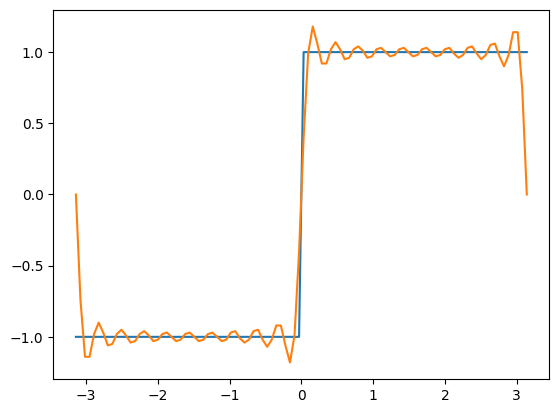

1.0622617379911603


In [464]:
# for the Euclidean norm firstly I need a function f(theta[i]) - which is my accurate square wave 
# maybe I could use the np.linalg.norm from the summative 

ftheta = np.linspace(-np.pi, np.pi, D)
for i in range(D):
   if -np.pi <= ftheta[i] <= 0 :
            ftheta[i] = -1
   elif 0 <= ftheta[i] <= np.pi:
      ftheta[i] = 1

thetaplots = np.linspace(-np.pi, np.pi, D)
plt.plot(thetaplots, ftheta)
plt.plot(thetaplots, plotable)
plt.show()

norm = np.linalg.norm(plotable[1:len(plotable)-1] - ftheta[1 : len(ftheta)-1] )   # have to exclude the boundary values for a valid euclidean norm
print(norm)               # norm here is really high this could be because i have done it wrong or it could be due to the gibbs phenonoma
    

In [465]:
print(ftheta)

[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]


In [466]:
N_list = [ 4,8,12,16,20,24,28,32, 34]         # reduced due to overflow on higher values 

norms = np.zeros(len(N_list))

for i in range(len(N_list)):                                 # The euclidean norm here is all wrong the values are much too high 
    A = simulation(N_list[i])
    slice = A[D-1, :]

    norms[i] = np.linalg.norm(slice[2: len(slice) -2 ] - ftheta[2: len(ftheta)-2])  # excluding thoes outer values for a decent euclidean norm 

print(norms)

[1.76504927 1.14421167 0.8887628  0.68429133 0.48636201 0.31594022
 0.21685503 0.28248795        nan]


C:\Users\peter\AppData\Local\Temp\ipykernel_58460\3728005781.py:25: RuntimeWarning: divide by zero encountered in divide
  U[:, j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )
C:\Users\peter\AppData\Local\Temp\ipykernel_58460\3728005781.py:25: RuntimeWarning: invalid value encountered in divide
  U[:, j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )
C:\Users\peter\AppData\Local\Temp\ipykernel_58460\3728005781.py:25: RuntimeWarning: invalid value encountered in add
  U[:, j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )


eqn destabilises at around n = 30, but shows good convergence unitl then. 

<function matplotlib.pyplot.show(close=None, block=None)>

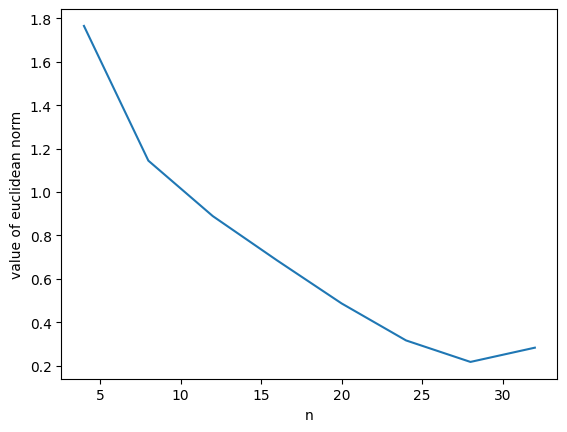

In [467]:
plt.plot(N_list, norms)
plt.xlabel('n')
plt.ylabel('value of euclidean norm')
plt.show

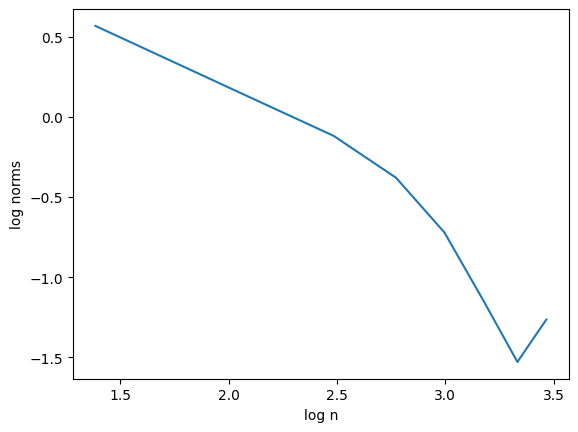

In [468]:
plt.plot(np.log(N_list), np.log(norms))
plt.xlabel('log n')
plt.ylabel('log norms')
plt.show()

## Numerical solution 

### Without the 1/r and 1/r^2 terms (Incorrect for polar)

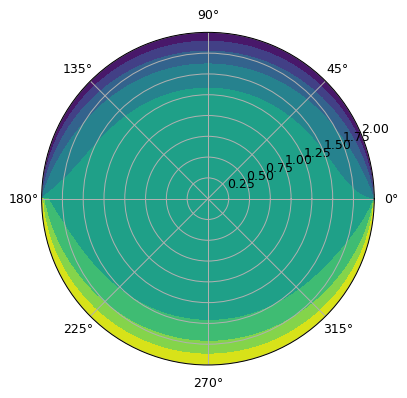

In [469]:
max_iters = 500

length_r = 100
length_theta = 100

radius = 2


the_top_temp = 100
the_bot_temp = -100
r_zero = 0

filler_value = 10


#r, theta = np.meshgrid(np.arange(0, length_r), np.arange(0,length_theta))  

r = np.linspace(0, radius , length_r)  # slices of radius of whatever length_r is set to
theta = np.linspace(-np.pi, np.pi , length_theta) # slices of -pi to pi of length_theta 

#r, theta = np.meshgrid(np.linspace(0, radius , length_r), np.linspace(-np.pi, np.pi , length_theta) )


u = np.empty((length_r, length_theta))
u.fill(filler_value)

# DOING ALL THE BOUNDARY CONDITIONS BY ARRAY SLICING 
u[length_r-1, (length_r//2): length_r] = the_bot_temp         # issue with / returning a floating point, not an integer, for indexing integers are required
u[length_r-1, 0: (length_r//2)] = the_top_temp             # this is done as python places polar arrays counter clockwise 
u[0, :] = r_zero


for iteration in range(max_iters):
    for i in range(1, (length_r -1)): # need to skip over boundary points that we have defined to avoid iterating over them. 
        for j in range(length_theta-1): #(1, (length_theta -1)):
            u[i,j] = 0.25* (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1])   # this is the formular for the cartesian not polar h here is 1 so h^2 = 1 hence stuff/1 = stuff



#plt.contourf(theta,r , u)
#plt.show()

plt.subplots(dpi = 90 , subplot_kw=dict(projection = 'polar'))     # maybe the tightening side needs to be on the x axis  thats why this works 
plt.contourf(theta, r ,u)   
plt.show()


In [470]:
# I STILL THINK THIS ITTERATION IS INCORRECT AS IT DOES NOT LOOK LIKE THE FOURIER TRANSFORM< the iteration does not account for the 1/r and 1/r^2 terms in the laplacian 
#jobs to do
# get your arrays straight, figure out why it is plotting weirdly, and not taking inputs in r,theta format always 
#figure out the iteratve formula not accounting for the polar domain and 1/r & 1/r^2 terms in the laplacian, or just the general squeezing of the coordinate system./////
# fix the fact that the hot and the colds are the wrong way round for your analytical solution. MASSIVE PROBLEM

### With the 1/r and 1/r^2 terms (correct numerical solution)

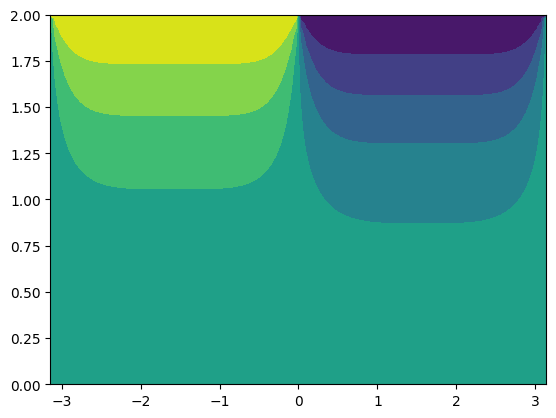

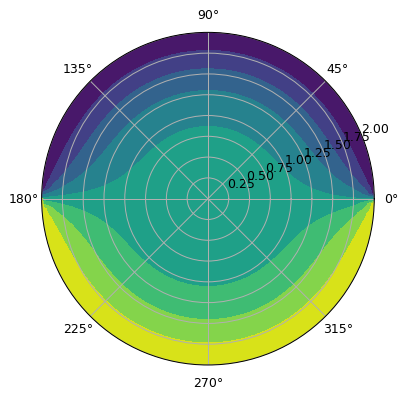

0.01578814480698274
0.0001989187837890479


In [471]:
max_iters = 500

length_r = 100
length_theta = 100

radius = 2



the_top_temp = 100
the_bot_temp = -100
r_zero = 0

filler_value = 10


#r, theta = np.meshgrid(np.arange(0, length_r), np.arange(0,length_theta))  

r = np.linspace(0, radius , length_r)  # slices of radius of whatever length_r is set to
theta = np.linspace(-np.pi, np.pi , length_theta) # slices of -pi to pi of length_theta 

#r, theta = np.meshgrid(np.linspace(0, radius , length_r), np.linspace(-np.pi, np.pi , length_theta) )


u = np.empty((length_r, length_theta))
u.fill(filler_value)

# DOING ALL THE BOUNDARY CONDITIONS BY ARRAY SLICING 
u[length_r-1, 0: (length_r//2)] = the_top_temp             # this is done as python places polar arrays counter clockwise 
u[length_r-1, (length_r//2): length_r] = the_bot_temp         # issue with / returning a floating point, not an integer, for indexing integers are required
u[0, :] = r_zero

#/////////////////////////////////////////Definintions of polar laplace terms 
#del_r_squ = (radius/length_r)**2                             # (2/100)**2 = 0.0004
#del_theta_squ =  ((2*np.pi) / length_theta)**2               # (6.3/100) = 0.0063
#r_squ = radius**2                                            # (2**2)    = 4 
#use radius for r                                            # 2         = 2 
#two_del_r = 2*(radius/length_r)                              #  2*(2/100)= 0.04

#multiplier = (del_r_squ*r_squ*del_theta_squ) / (2*(r_squ*del_theta_squ)) + 2*(del_r_squ)

#multiplier = ((r[i] - r[i-1])**2)* ((r[i])**2) * ((theta[j] - theta[j-1])**2) / (2*(((r[i])**2) * (theta[j] - theta[j-1])**2)) # MAIN BUG FOUND why have you left out the 2delta r bit 
#///////////////////////////////////////////
for iteration in range(max_iters):
    for i in range(1, (length_r -1)): # need to skip over boundary points that we have defined to avoid iterating over them.
        
        X = (r[i] - r[i-1])**2  # delta radius(i) squared                 # CHANGE IN R is just r2 -r1
        Y = (r[i] * (2*(r[i] - r[i-1])))          # radius(i) times 2 times delta r     
    

        for j in range(1, length_theta-1): #(1, (length_theta -1)):

            Z = ((r[i])**2 )*((theta[j] - theta[j-1])**2)  # 
            multiplier = ((r[i] - r[i-1])**2)* ((r[i])**2) * ((theta[j] - theta[j-1])**2) / ( (2*(((r[i])**2) * (theta[j] - theta[j-1])**2)) + 2*((r[i] - r[i -1])**2) )

            u[i,j] =  (multiplier) *( (u[i-1,j]/ X) + (u[i+1,j]/ X) + (u[i+1,j]/ Y) + (-u[i-1,j]/ Y) + (u[i,j-1]/ Z) + (u[i,j+1]/ Z) ) #(multiplier) *



#  u[i,j] = ((del_r_squ*r_squ*del_theta_squ) / (2*(r_squ*del_theta_squ)) + 2*(del_r_squ) ) * ( (u[i-1,j]/ del_r_squ) + (u[i+1,j]/del_r_squ) + (u[i+1,j]/(radius*two_del_r)) + (-u[i-1,j]/(radius*two_del_r)) + (u[i,j-1]/(r_squ*del_theta_squ)) + (u[i,j+1]/(r_squ*del_theta_squ)) )

plt.contourf(theta,r , u)
plt.show()

plt.subplots(dpi = 90 , subplot_kw=dict(projection = 'polar'))     # maybe the tightening side needs to be on the x axis  thats why this works because It folds on theta
plt.contourf(theta, r ,u)   
plt.show()



print(Z)
print(multiplier)
#this may be because r is not a static value and it varies at that point in the discretisation. so i have to change my code 

#I think im itterating over one of the boudaries here / fixed 

In [472]:
u[length_r-1, :]

array([ 100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100.])